# Overlapping Intervals: Figures 15, 16, And 17

This notebook was added for Appendix B.7. The `overlapping-spans` tag contains both control and overlapping-span runs; the report figures use stride-2 overlap with three and four attention heads.


In [1]:
from analysis.utils import fetch_runs, fetch_run_data, plot_kl_divergence_simple, plot_separated_heads, plot_val_loss_simple, report_head_color_map
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
TAG = "overlapping-spans"
THREE_HEAD_RUN = "c9pd8yft"
FOUR_HEAD_RUN = "d5w941d1"

rows = []
for run in fetch_runs(tags_any=[TAG]):
    rows.append({"tag": TAG, "run_id": run.id, "name": run.name, "state": run.state})
pd.DataFrame(rows)


,tag,run_id,name,state
0,overlapping-spans,c9pd8yft,gentle-dragon-1937,crashed
1,overlapping-spans,m8xw3gz6,rural-forest-1936,crashed
2,overlapping-spans,d5w941d1,smooth-wood-1938,crashed


## Figure 15: Four-Head KL Divergence

The four-head model keeps the staged KL structure even when intervals overlap by stride 2.


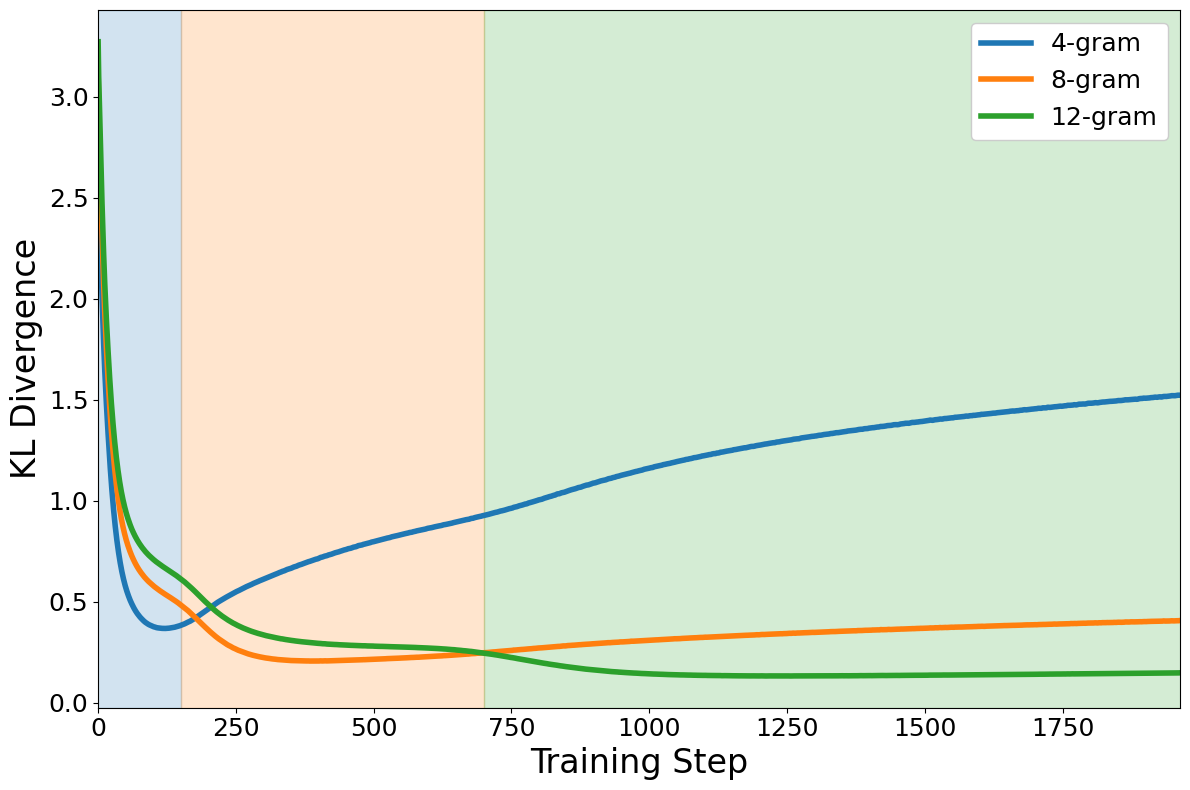

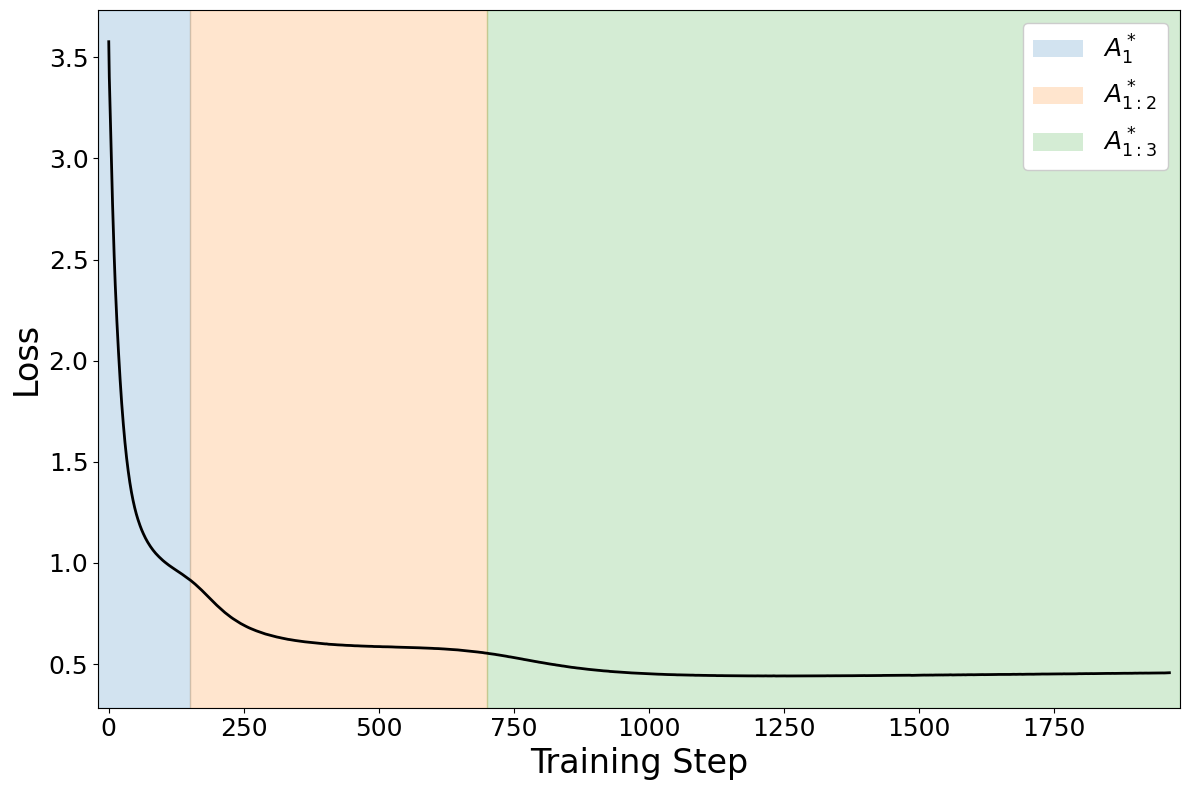

In [3]:
conf = fetch_run_data(FOUR_HEAD_RUN, metrics=["val_loss"])["config"]
assert conf["student"]["num_heads"] == 4
assert conf["teacher"]["stride"] == 2

plot_kl_divergence_simple(
    run_id=FOUR_HEAD_RUN,
    learnable=True,
    divergence_steps=[2150, 2700],
    shift_steps=2000,
    save_name=output_path("kl-overlapping-4heads"),
)

plot_val_loss_simple(
    run_id=FOUR_HEAD_RUN,
    divergence_steps=[2150, 2700],
    shift_steps=2000,
    save_name=output_path("val-loss-overlapping-4heads"),
)


## Figure 16: Three-Head Attention

With three heads and overlapping spans, the learned attention order is less canonical because positions can contribute to multiple intervals.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


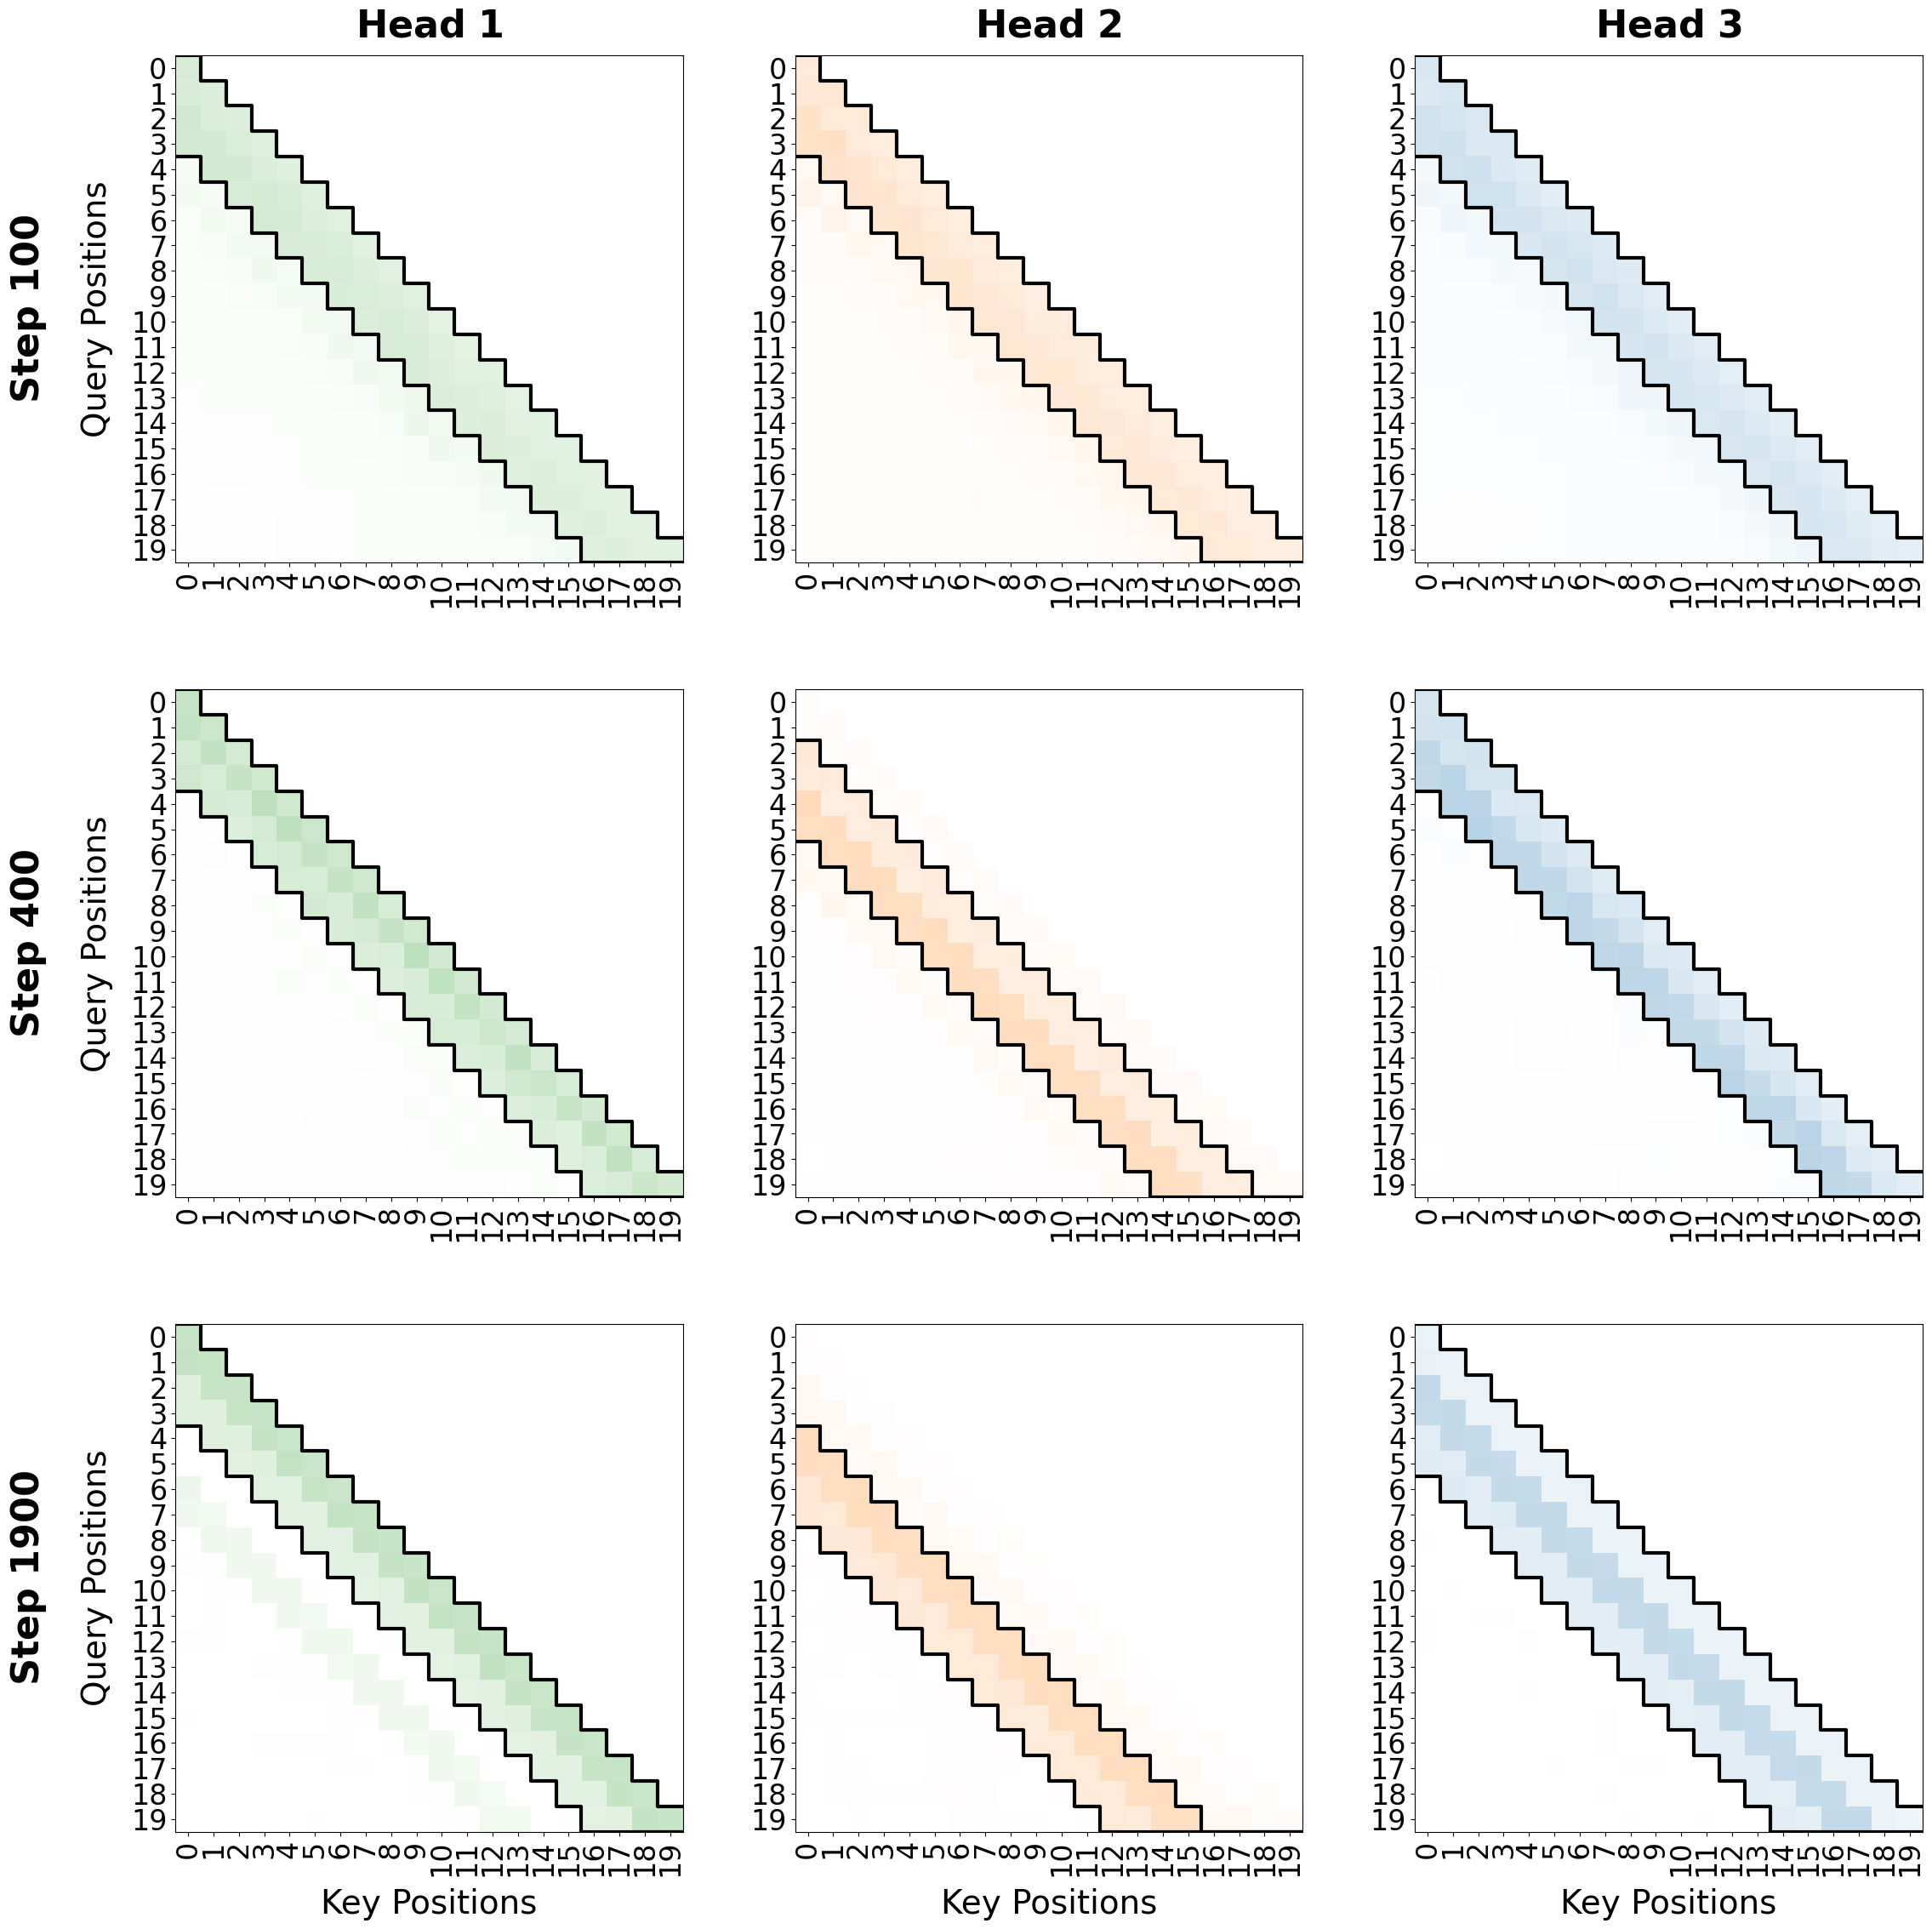

In [4]:
conf = fetch_run_data(THREE_HEAD_RUN, metrics=["val_loss"])["config"]
assert conf["student"]["num_heads"] == 3
assert conf["teacher"]["stride"] == 2

plot_separated_heads(
    THREE_HEAD_RUN,
    steps=[100, 400, 1900],
    frequency=50,
    split="val",
    head_colors=report_head_color_map([2, 1, 0]),
    staircases={
        (0, 0): [0, -4], (0, 1): [0, -4], (0, 2): [0, -4],
        (1, 0): [0, -4], (1, 1): [-2, -6], (1, 2): [0, -4],
        (2, 0): [0, -4], (2, 1): [-4, -8], (2, 2): [0, -6],
    },
    save_name=output_path("attention-overlapping-3heads"),
)


## Figure 17: Four-Head Attention

The four-head attention grid shows specialization across overlapping intervals with one extra head available.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


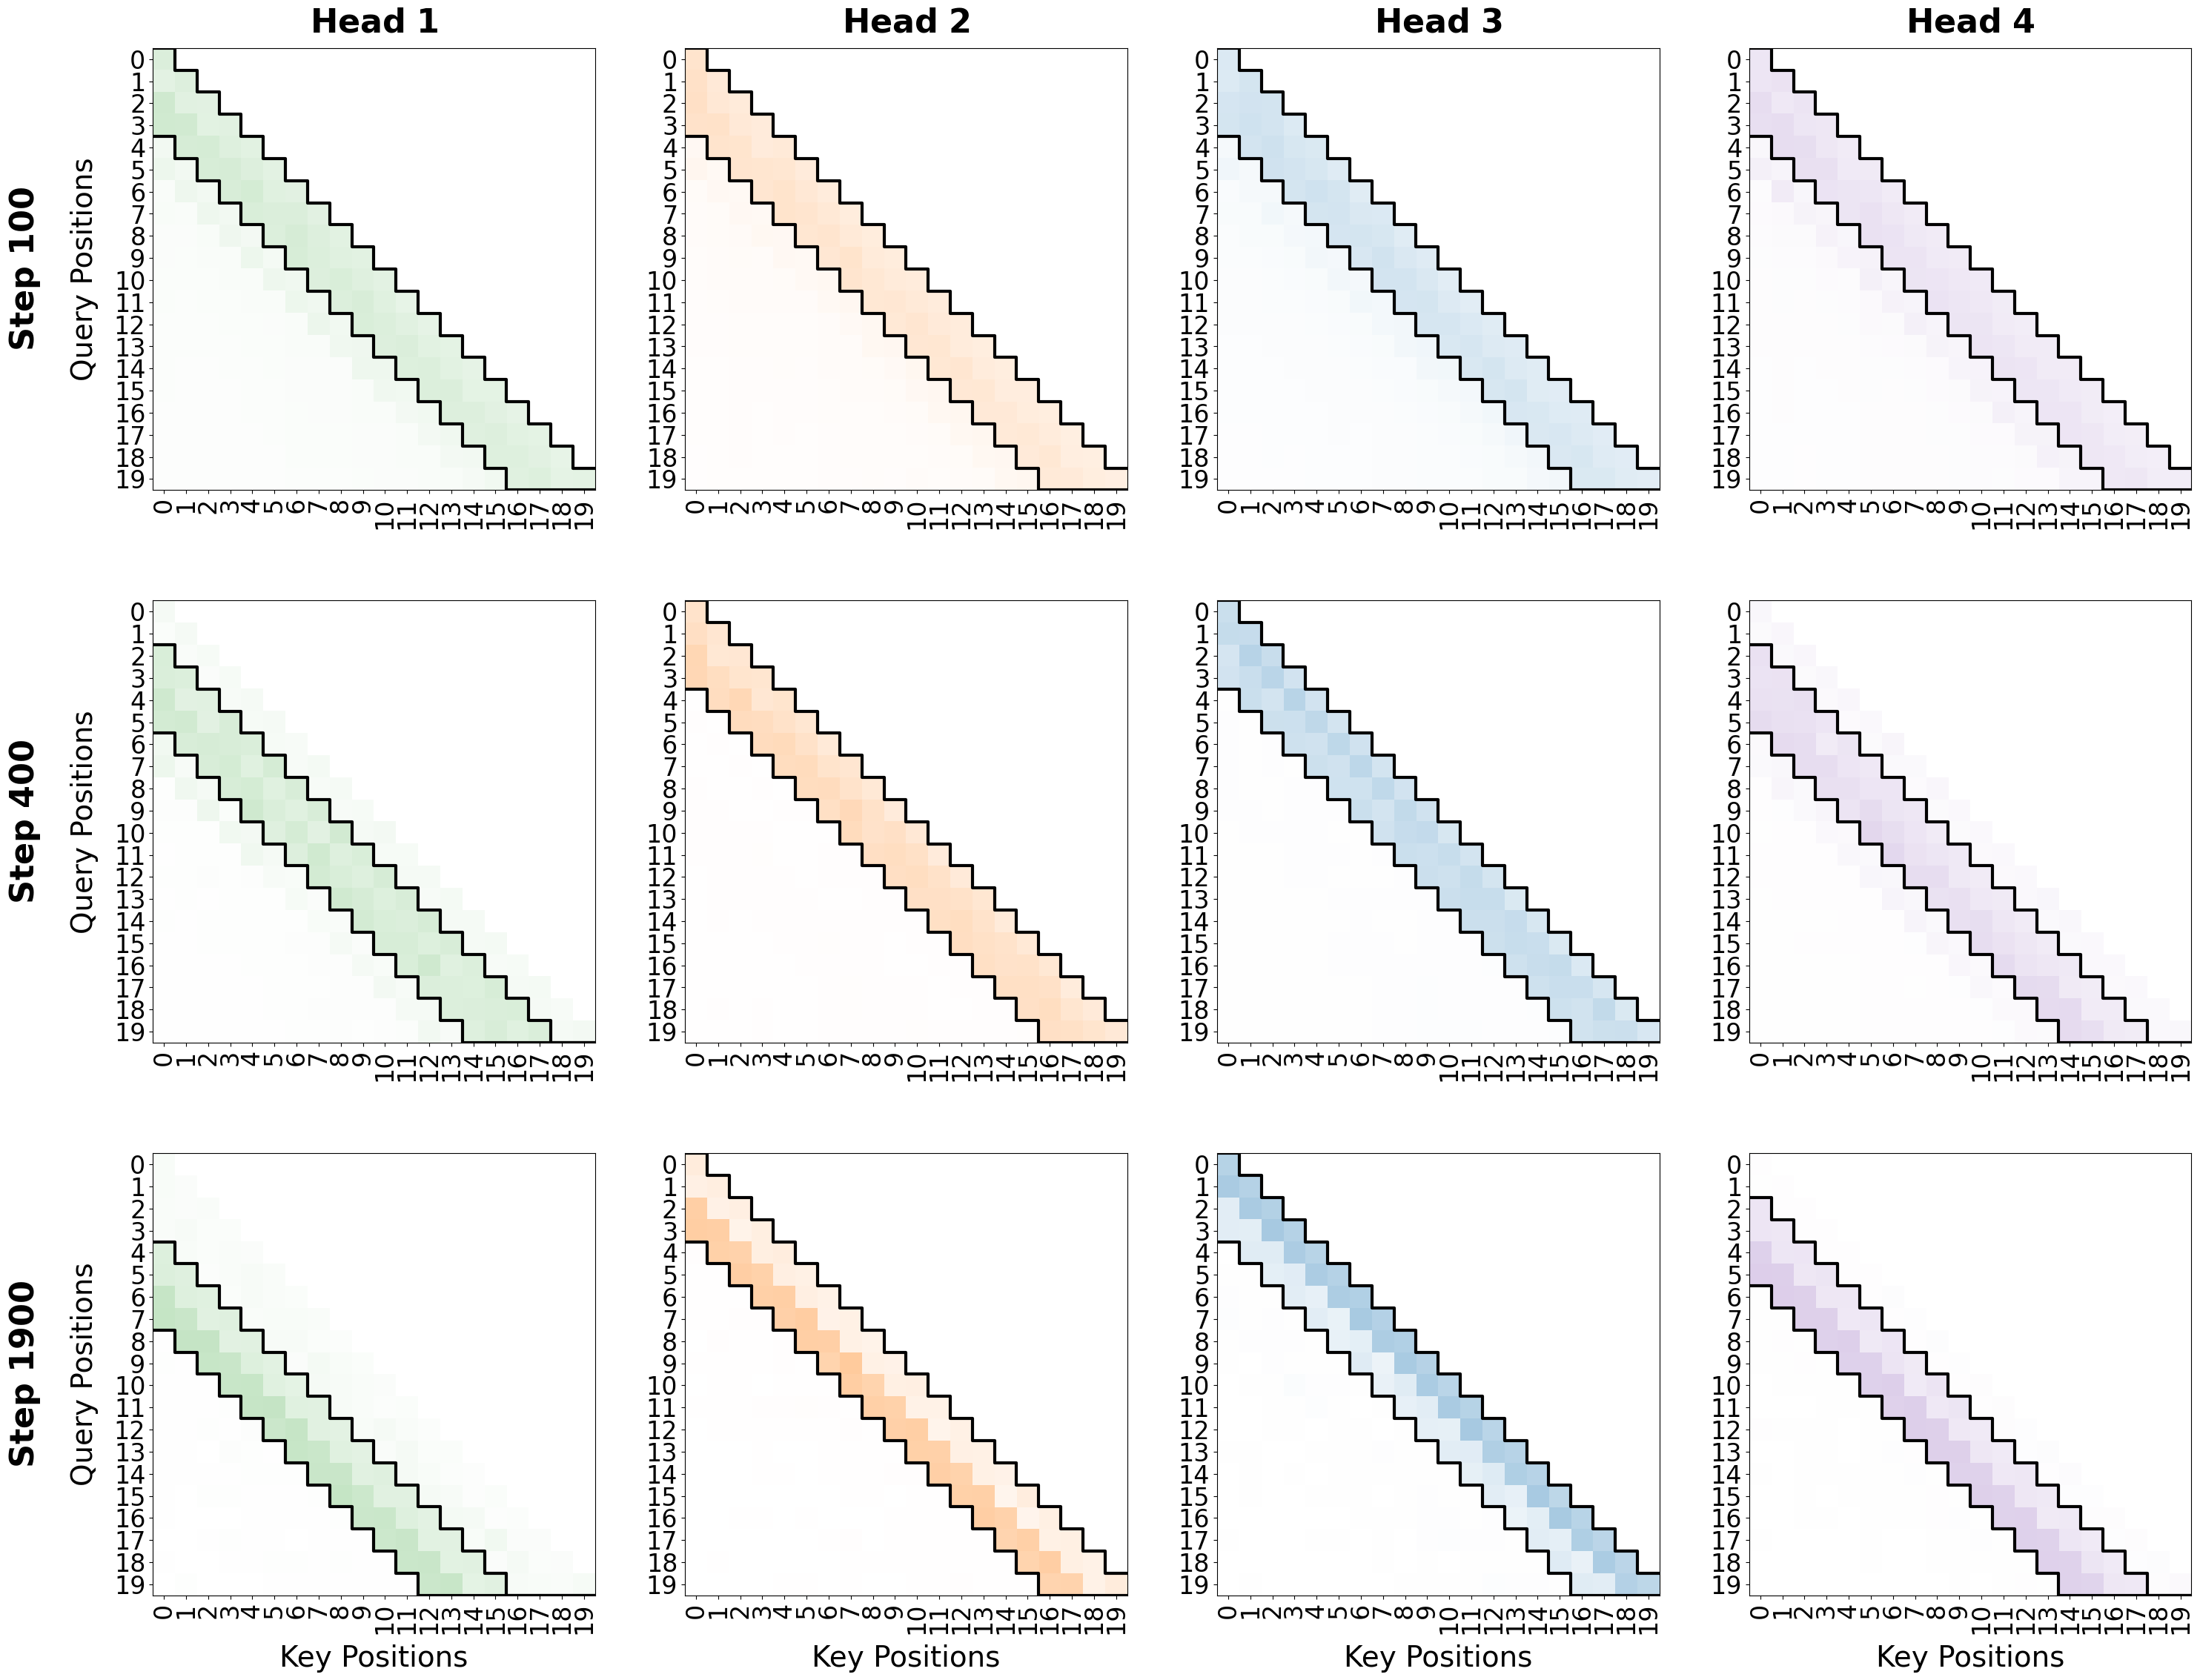

In [5]:
plot_separated_heads(
    FOUR_HEAD_RUN,
    steps=[100, 400, 1900],
    frequency=50,
    split="val",
    head_colors=report_head_color_map([2, 1, 0, 3]),
    staircases={
        (0, 0): [0, -4], (0, 1): [0, -4], (0, 2): [0, -4], (0, 3): [0, -4],
        (1, 0): [-2, -6], (1, 1): [0, -4], (1, 2): [0, -4], (1, 3): [-2, -6],
        (2, 0): [-4, -8], (2, 1): [0, -4], (2, 2): [0, -4], (2, 3): [-2, -6],
    },
    save_name=output_path("attention-overlapping-4heads"),
)
